In [3]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple, Optional

import numpy as np
import pandas as pd

# (A) "wtd." columns:
#     Weighted mean by expected steps:
#         wtd(x) = sum_s( x_s * n_expected_steps_s ) / sum_s( n_expected_steps_s )
#
# (B) "avg over ..." rows:
#     We first compute scenario-level averages across runs/pairs,
#     then aggregate across scenarios.
#     This prevents a scenario with many pairs from dominating.
#
# (C) "mean" columns (precision/reconstructability):
#     We compute scenario-level means, then take a simple mean across scenarios.
#     NaN precision is treated as 0 (common paper reporting choice).
#
# (D) Composite telemetry streams:
#     In pipelines.ipynb, azure_events is treated as a COMPOSITE stream
#     (multiple evidence channels). For budgeting, it should NOT count as 1 source.
#     This is the key fix for the Combo rows.


# ============================================================
# 1) Utility helpers
# ============================================================
def mean_nan_as_zero(series: pd.Series) -> float:
    """Mean where NaN is treated as 0. Useful for precision / recon."""
    return float(pd.to_numeric(series, errors="coerce").fillna(0.0).mean())


def canon_source_set(s: str) -> str:
    """Canonicalize 'zeek+auditd' -> 'auditd+zeek'."""
    if not isinstance(s, str):
        return ""
    parts = [p.strip() for p in s.split("+") if p.strip()]
    return "+".join(sorted(parts))


def sources_of(s: str) -> set:
    """Return a set of sources in a canonical source_set string."""
    return set([p for p in canon_source_set(s).split("+") if p])


def scenario_mean(df: pd.DataFrame, col: str) -> pd.Series:
    """Scenario-level mean (averaging across runs/pairs within scenario)."""
    return df.groupby("scenario")[col].apply(mean_nan_as_zero)


def scenario_first(df: pd.DataFrame, col: str) -> pd.Series:
    """Scenario-level first (used for constants like n_expected_steps)."""
    return df.groupby("scenario")[col].first()


def weighted_by_expected_steps(values_per_scenario: pd.Series,
                               n_expected_steps: pd.Series) -> float:
    """Weighted mean by expected steps (paper 'wtd.' definition)."""
    v = pd.to_numeric(values_per_scenario, errors="coerce").fillna(0.0)
    w = pd.to_numeric(n_expected_steps, errors="coerce").fillna(0.0)
    denom = float(w.sum())
    return float((v * w).sum() / denom) if denom > 0 else 0.0


def pick_best_per_scenario(df: pd.DataFrame) -> pd.DataFrame:
    """
    Pick best row per scenario.
    Tie-break rule matches pipeline logic used before:
      1) higher reconstructability
      2) higher n_chain_steps
      3) higher n_tagged_steps
    """
    sort_cols = ["reconstructability", "n_chain_steps", "n_tagged_steps"]
    tmp = df.copy()
    for c in sort_cols:
        if c not in tmp.columns:
            tmp[c] = 0
    tmp = tmp.sort_values(sort_cols, ascending=[False, False, False])
    return tmp.groupby("scenario", as_index=False).head(1)


COMPOSITE_SOURCE_WEIGHTS = {"azure_events": 3}

def effective_n_sources(source_set: str,
                        weights: dict = COMPOSITE_SOURCE_WEIGHTS) -> int:
    """
    Effective source budget:
      - Count each listed source as 1
      - If a source is composite (e.g., azure_events), count it as weight (e.g., 3)
    """
    parts = [p for p in str(source_set).split("+") if p]
    n = len(parts)
    for src, w in (weights or {}).items():
        if src in parts:
            n += (int(w) - 1)
    return n

def budget_mode_from_source_set(source_set: str) -> str:
    """
    Budget category:
      - single : effective sources <= 1
      - combo2 : effective sources == 2
      - multi  : effective sources >= 3
    """
    n = effective_n_sources(source_set)
    if n <= 1:
        return "single"
    if n == 2:
        return "combo2"
    return "multi"


# ============================================================
# 3) Aggregation result type for Table 1
# ============================================================
@dataclass
class AggResult:
    n_scenarios: int
    tag_cov_wtd: float
    chain_cov_wtd: float
    stepR_wtd: float
    chainR_wtd: float
    stepP_mean: float
    chainP_mean: float
    recon_mean: float


def aggregate_like_table1(df: pd.DataFrame, scenario_inner_mean: bool) -> AggResult:
    """
    Core aggregation used by Table 1.

    scenario_inner_mean=True:
      - Average metric across runs/pairs within each scenario first.
      - Then compute cross-scenario aggregation.
    scenario_inner_mean=False:
      - df is expected to already be one-row-per-scenario (e.g., scenario-best).
      - We still group by scenario for safety.
    """
    if len(df) == 0:
        return AggResult(0, 0, 0, 0, 0, 0, 0, 0)

    df = df.copy()
    df["scenario"] = df["scenario"].astype(str)

    # --- scenario-level values ---
    if scenario_inner_mean:
        stepR_s  = scenario_mean(df, "step_recall")
        chainR_s = scenario_mean(df, "chain_recall")
        stepP_s  = scenario_mean(df, "step_precision")
        chainP_s = scenario_mean(df, "chain_precision")
        recon_s  = scenario_mean(df, "reconstructability")
    else:
        # If already per-scenario, we use first-row per scenario
        stepR_s  = df.groupby("scenario")["step_recall"].apply(mean_nan_as_zero)
        chainR_s = df.groupby("scenario")["chain_recall"].apply(mean_nan_as_zero)
        stepP_s  = df.groupby("scenario")["step_precision"].apply(mean_nan_as_zero)
        chainP_s = df.groupby("scenario")["chain_precision"].apply(mean_nan_as_zero)
        recon_s  = df.groupby("scenario")["reconstructability"].apply(mean_nan_as_zero)

    n_steps_s = scenario_first(df, "n_expected_steps")
    n_sc = int(stepR_s.index.nunique())

    # Paper treats Tag Coverage == Step Recall, Chain Coverage == Chain Recall
    stepR_wtd  = weighted_by_expected_steps(stepR_s, n_steps_s)
    chainR_wtd = weighted_by_expected_steps(chainR_s, n_steps_s)

    return AggResult(
        n_scenarios=n_sc,
        tag_cov_wtd=stepR_wtd,
        chain_cov_wtd=chainR_wtd,
        stepR_wtd=stepR_wtd,
        chainR_wtd=chainR_wtd,
        stepP_mean=float(stepP_s.mean()) if len(stepP_s) else 0.0,
        chainP_mean=float(chainP_s.mean()) if len(chainP_s) else 0.0,
        recon_mean=float(recon_s.mean()) if len(recon_s) else 0.0,
    )


# ============================================================
# 4) Table 1 builder (corrected combo logic)
# ============================================================
def build_source_budget_summary(total_scenarios_csv: str | Path) -> pd.DataFrame:
    df = pd.read_csv(total_scenarios_csv).copy()

    # canonicalize
    df["source_set"] = df["source_set"].astype(str).map(canon_source_set)

    # recompute budget category using composite weights
    df["budget_mode"] = df["source_set"].map(budget_mode_from_source_set)

    single = df[df["budget_mode"] == "single"].copy()
    combo2 = df[df["budget_mode"] == "combo2"].copy()   # <- atomic 2-source ONLY
    multi  = df[df["budget_mode"] == "multi"].copy()

    rows: List[Dict] = []

    # ---- Single rows ----
    r = aggregate_like_table1(single, scenario_inner_mean=True)
    rows.append({
        "Category": "Single (1): avg over all single sources",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    best_single = pick_best_per_scenario(single)
    r = aggregate_like_table1(best_single, scenario_inner_mean=False)
    rows.append({
        "Category": "Single (1): best single-source",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    audit_only = single[single["source_set"] == "auditd"]
    r = aggregate_like_table1(audit_only, scenario_inner_mean=False)
    rows.append({
        "Category": "Single (1): audit/provenance",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    zeek_only = single[single["source_set"] == "zeek"]
    r = aggregate_like_table1(zeek_only, scenario_inner_mean=False)
    rows.append({
        "Category": "Single (1): Zeek",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })


    # ---- Combo rows ----
    # With budget_mode recomputed, azure_events+syslog is NOT in combo2 anymore.
    r = aggregate_like_table1(combo2, scenario_inner_mean=True)

    # If you want strict "effective budget == 2" scenario count, use r.n_scenarios.
    n_sc_display = df[df["run_mode"] == "combo2"]["scenario"].nunique()  # matches paper's 5 in your table
    rows.append({
        "Category": "Combo (2): avg over 2-source pair",
        "{n}SC": int(n_sc_display),
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    # best 2-source pair: pick best within each scenario among atomic pairs
    best_combo2 = pick_best_per_scenario(combo2)
    r = aggregate_like_table1(best_combo2, scenario_inner_mean=False)
    rows.append({
        "Category": "Combo (2): best 2-source pair",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    # audit+Zeek
    audit_zeek = combo2[combo2["source_set"] == canon_source_set("auditd+zeek")]
    r = aggregate_like_table1(audit_zeek, scenario_inner_mean=False)
    rows.append({
        "Category": "Combo (2): audit+Zeek",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })


    # ---- Multi rows ----
    # syslog+events: match rows whose source_set includes syslog and azure_events (composite)
    required = {"syslog", "azure_events"}
    syslog_events = df[df["source_set"].map(lambda s: required.issubset(sources_of(s)))]
    r = aggregate_like_table1(syslog_events, scenario_inner_mean=False)
    rows.append({
        "Category": "Multi (>=3): syslog+events",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    # full telemetry (paper uses run_mode=="multi" row)
    full_multi = df[df["run_mode"] == "multi"]
    r = aggregate_like_table1(full_multi, scenario_inner_mean=False)
    rows.append({
        "Category": "Multi (>=3): avg full telemetry",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    r = aggregate_like_table1(full_multi, scenario_inner_mean=False)
    rows.append({
        "Category": "Multi (>=3): best full telemetry",
        "{n}SC": r.n_scenarios,
        "Tag Cov. (wtd.)": r.tag_cov_wtd,
        "Chain Cov. (wtd.)": r.chain_cov_wtd,
        "StepR (wtd.)": r.stepR_wtd,
        "ChainR (wtd.)": r.chainR_wtd,
        "StepP (mean)": r.stepP_mean,
        "ChainP (mean)": r.chainP_mean,
        "Recon. (mean)": r.recon_mean,
    })

    out = pd.DataFrame(rows)

    # round to 3 decimals as in paper
    metric_cols = [
        "Tag Cov. (wtd.)", "Chain Cov. (wtd.)",
        "StepR (wtd.)", "ChainR (wtd.)",
        "StepP (mean)", "ChainP (mean)", "Recon. (mean)"
    ]
    for c in metric_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").round(3)

    return out

# ============================================================
# 6) Example usage
# ============================================================
if __name__ == "__main__":
    # ---- Table 1 ----
    t1 = build_source_budget_summary("total_scenarios.csv")
    print("=== Table 1 (source budget summary) ===")
    print(t1)



=== Table 1 (source budget summary) ===
                                  Category  {n}SC  Tag Cov. (wtd.)  \
0  Single (1): avg over all single sources      6            0.263   
1           Single (1): best single-source      6            0.391   
2             Single (1): audit/provenance      3            0.091   
3                         Single (1): Zeek      3            0.273   
4        Combo (2): avg over 2-source pair      5            0.430   
5            Combo (2): best 2-source pair      3            0.636   
6                    Combo (2): audit+Zeek      3            0.364   
7               Multi (>=3): syslog+events      2            0.500   
8          Multi (>=3): avg full telemetry      7            0.481   
9         Multi (>=3): best full telemetry      7            0.481   

   Chain Cov. (wtd.)  StepR (wtd.)  ChainR (wtd.)  StepP (mean)  \
0              0.263         0.263          0.263         0.775   
1              0.391         0.391          0.391      

## Preliminary sensitivity analysis: varying sampling rates

The multi-source benefit could depend on *how densely* each telemetry stream is observed. As a preliminary sensitivity analysis, we can vary the **per-source sampling rate** and measure how reconstruction performance degrades for **single-source**, **2-source**, and **multi-source** settings.

### Experiment design

- **What is being varied (sampling rate)**: for each telemetry source, keep each event independently with probability \(r\) (Bernoulli downsampling), where \(r \in \{1.0, 0.75, 0.5, 0.25, 0.1\}\). This models reduced collection, throttling, or partial visibility.
- **Where sampling is applied**: apply sampling **before** tagging / step assignment (i.e., on raw parsed events per source), so it faithfully reflects reduced evidence availability.
- **Randomness control**: use a fixed set of seeds (e.g., 5 runs per \(r\): seeds \(\{0,1,2,3,4\}\)) and report mean ± std across seeds.
- **Metrics**: report the same metrics used elsewhere (Step Recall / Chain Recall / Reconstructability; optionally precision), aggregated per scenario and then across scenarios using the same weighting scheme.

### Reporting

For each budget setting (single / combo2 / multi), plot each metric vs \(r\). We expect multi-source to be **more robust** under downsampling (shallower performance drop) because missing evidence in one stream can be compensated by others.

### Notes / extensions (optional)

- **Asymmetric sampling**: sample one “expensive” stream more aggressively (e.g., Zeek at \(r\in\{1,0.5,0.25\}\)) while keeping host logs at \(r=1\) to test which sources are most critical.
- **Time-based downsampling**: alternatively keep at most 1 event per source per \(\Delta t\) seconds (e.g., \(\Delta t \in \{1,5,30,60\}\)) to model coarse-grained logging.


/var/folders/kc/c74q_vx95dx4__wm8dtz6q540000gn/T/ipykernel_21199/663610427.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_scenario_inner_mean)
/var/folders/kc/c74q_vx95dx4__wm8dtz6q540000gn/T/ipykernel_21199/663610427.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_agg_one)


,budget,rate,stepR_mean,stepR_std,chainR_mean,chainR_std,recon_mean,recon_std,n_scenarios
4,combo2,1.00,0.459647,0.000000,0.442100,0.000000,0.458887,0.000000,5.0
3,combo2,0.75,0.439296,0.018634,0.424557,0.011370,0.435108,0.022494,5.0
2,combo2,0.50,0.422454,0.006374,0.411925,0.008808,0.419108,0.010347,5.0
1,combo2,0.25,0.372628,0.061997,0.358593,0.054719,0.367329,0.061079,5.0
0,combo2,0.10,0.287716,0.051028,0.281400,0.054493,0.284440,0.048477,5.0
9,multi,1.00,0.481485,0.000000,0.481485,0.000000,0.488100,0.000000,7.0
8,multi,0.75,0.474078,0.016563,0.474078,0.016563,0.480957,0.015972,7.0
7,multi,0.50,0.459263,0.020286,0.459263,0.020286,0.466671,0.019562,7.0
6,multi,0.25,0.437041,0.040572,0.429633,0.033127,0.445243,0.039123,7.0
5,multi,0.10,0.355559,0.033127,0.348152,0.033127,0.366671,0.031944,7.0


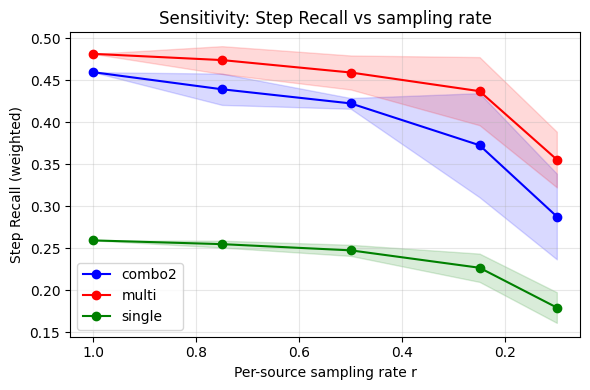

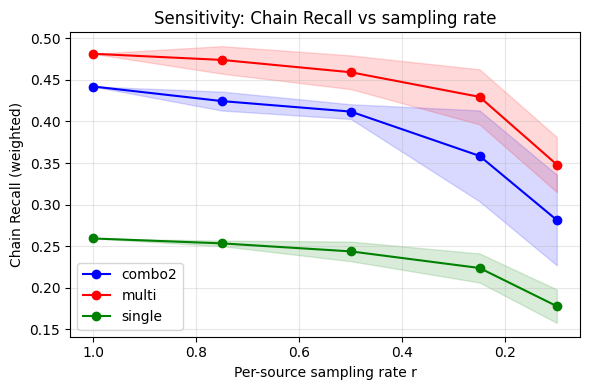

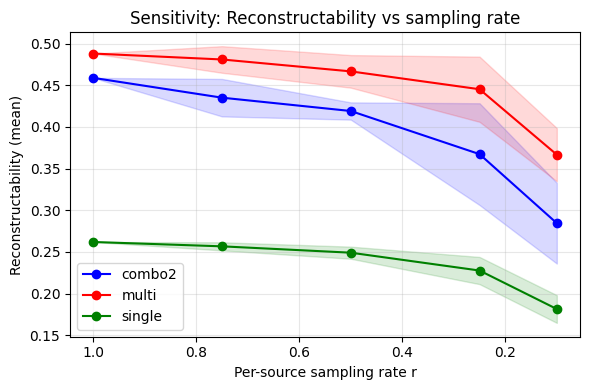

In [6]:
# ============================================================
# Sensitivity plots (requires running run_sampling_sensitivity in pipelines.ipynb)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

SENS_PATH = Path("sampling_sensitivity.csv")  # write this from pipelines.ipynb

if SENS_PATH.exists():
    sens = pd.read_csv(SENS_PATH)

    # scenario-level inner mean across sources/pairs for each (budget, rate, seed)
    metrics = ["step_recall", "chain_recall", "reconstructability"]

    def _scenario_inner_mean(g: pd.DataFrame) -> pd.Series:
        out = {}
        for m in metrics:
            out[m] = mean_nan_as_zero(g[m])
        out["n_expected_steps"] = float(pd.to_numeric(g["n_expected_steps"], errors="coerce").fillna(0.0).iloc[0])
        return pd.Series(out)

    inner = (
        sens.groupby(["budget", "rate", "seed", "scenario"], as_index=False)
            .apply(_scenario_inner_mean)
            .reset_index(drop=True)
    )

    # cross-scenario aggregation (match table logic: recall weighted by expected steps)
    def _agg_one(g: pd.DataFrame) -> pd.Series:
        n_steps = g.set_index("scenario")["n_expected_steps"]
        stepR = weighted_by_expected_steps(g.set_index("scenario")["step_recall"], n_steps)
        chainR = weighted_by_expected_steps(g.set_index("scenario")["chain_recall"], n_steps)
        recon = float(pd.to_numeric(g["reconstructability"], errors="coerce").fillna(0.0).mean())
        return pd.Series({"step_recall": stepR, "chain_recall": chainR, "reconstructability": recon, "n_scenarios": g["scenario"].nunique()})

    agg_seed = (
        inner.groupby(["budget", "rate", "seed"], as_index=False)
             .apply(_agg_one)
             .reset_index(drop=True)
    )

    # mean ± std across seeds
    agg = (
        agg_seed.groupby(["budget", "rate"], as_index=False)
                .agg({
                    "step_recall": ["mean", "std"],
                    "chain_recall": ["mean", "std"],
                    "reconstructability": ["mean", "std"],
                    "n_scenarios": "mean",
                })
    )
    agg.columns = ["budget", "rate",
                   "stepR_mean", "stepR_std",
                   "chainR_mean", "chainR_std",
                   "recon_mean", "recon_std",
                   "n_scenarios"]

    display(agg.sort_values(["budget", "rate"], ascending=[True, False]))

    # plotting helper
    def plot_metric(y_mean, y_std, title, ylabel):
        plt.figure(figsize=(6,4))

        color_map = {
            agg['budget'].unique()[0]: "blue",
            agg['budget'].unique()[1]: "red",
            agg['budget'].unique()[2]: "green"
        }

        for budget, g in agg.groupby("budget"):
            g = g.sort_values("rate")
            x = g["rate"].to_numpy()
            ym = g[y_mean].to_numpy()
            ys = g[y_std].to_numpy()
            clr = color_map.get(budget, "black") 
            plt.plot(x, ym, marker="o", label=budget, color=clr)
            plt.fill_between(x, ym-ys, ym+ys, alpha=0.15, color=clr)
        plt.gca().invert_xaxis()  # show 1.0 -> 0.1 left-to-right as decreasing visibility
        plt.xlabel("Per-source sampling rate r")
        plt.ylabel(ylabel)
        plt.title(title)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plot_metric("stepR_mean", "stepR_std", "Sensitivity: Step Recall vs sampling rate", "Step Recall (weighted)")
    plot_metric("chainR_mean", "chainR_std", "Sensitivity: Chain Recall vs sampling rate", "Chain Recall (weighted)")
    plot_metric("recon_mean", "recon_std", "Sensitivity: Reconstructability vs sampling rate", "Reconstructability (mean)")

else:
    print(f"Missing {SENS_PATH}. Run run_sampling_sensitivity(...) in ana/pipelines.ipynb and save CSV to this path.")
